# 🧠 Deep Notes AI
## YouTube Knowledge Extraction & Knowledge Graph Platform

A **14-phase LangGraph pipeline** that transforms raw YouTube videos into a structured, queryable personal knowledge base.

---

### System Architecture

```
YouTube URLs
    │
    ▼
┌─────────────────────────────────────────────────────────┐
│                  LangGraph StateGraph                   │
│                                                         │
│  url_processor → transcript_extractor → note_generator │
│       │                                       │         │
│  [Validation]                         [GPT-4o-mini]    │
│                                               │         │
│  topic_extractor → topic_mapper → topic_canonicalizer  │
│  [GPT-4o-mini]      [SQLite]    [Embed+LLM dedup]     │
│                                               │         │
│  graph_writer → topic_aggregator → summary_generator  │
│  [Neo4j/SQLite]    [GPT-4o]        [GPT-4o-mini]      │
└─────────────────────────────────────────────────────────┘
    │
    ▼
┌──────────────────────────────────────────────┐
│              Storage Trinity                  │
│  SQLite (source) | Neo4j (graph) | Qdrant    │
└──────────────────────────────────────────────┘
    │
    ▼
query_video() | query_topic() | query_topic_summary()
```

### Technology Stack
| Component | Technology | Reason |
|-----------|-----------|--------|
| Orchestration | LangGraph 0.2+ | Production-grade stateful agent graphs |
| LLM Extraction | GPT-4o-mini | Cheap, fast, reliable JSON output |
| LLM Reasoning | GPT-4o | High-quality consolidation & aggregation |
| Embeddings | text-embedding-3-small | Best cost/quality for semantic search |
| Transcripts | youtube-transcript-api | No auth required |
| Schemas | Pydantic v2 | Type-safe, validated data models |
| Retry Logic | Tenacity | Exponential backoff for all API calls |
| Graph DB | Neo4j (optional) | Cypher traversal for topic relationships |
| Vector DB | Qdrant (in-memory) | Zero-infra semantic search |
| SQL DB | SQLite | Zero-infra source of truth, PostgreSQL-ready |


In [102]:
# ─── Core Imports ────────────────────────────────────────────────────
import os, re, json, uuid, sqlite3, logging, operator, hashlib
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any, TypedDict, Annotated, Literal
from enum import Enum
from dataclasses import dataclass
from functools import wraps
from concurrent.futures import ThreadPoolExecutor, as_completed

import tiktoken
from tenacity import (
    retry, stop_after_attempt, wait_exponential,
    retry_if_exception_type, before_sleep_log,
)
from pydantic import BaseModel, Field, field_validator, model_validator
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.messages import HumanMessage, SystemMessage

from langgraph.graph import StateGraph, END, START

from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

# Optional: youtube-transcript-api error types
try:
    from youtube_transcript_api._errors import (
        TranscriptsDisabled, NoTranscriptFound, VideoUnavailable,
    )
except ImportError:
    try:
        from youtube_transcript_api import (
            TranscriptsDisabled, NoTranscriptFound, VideoUnavailable,
        )
    except ImportError:
        TranscriptsDisabled = NoTranscriptFound = VideoUnavailable = Exception

# Optional Neo4j
try:
    from neo4j import GraphDatabase
    NEO4J_AVAILABLE = True
except ImportError:
    NEO4J_AVAILABLE = False

print("✅ All imports successful")
print(f"   Neo4j driver available: {NEO4J_AVAILABLE}")


✅ All imports successful
   Neo4j driver available: True


In [103]:
# ─── Configuration & Environment ─────────────────────────────────────
load_dotenv()

# -- API Keys --
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise EnvironmentError(
        "OPENAI_API_KEY not found.\n"
        "   Add it to your .env file:  OPENAI_API_KEY=sk-..."
    )
NVIDIA_API_KEY = os.getenv("NVIDIA_API_KEY")
if not NVIDIA_API_KEY:
    raise EnvironmentError(
        "NVIDIA_API_KEY not found.\n"
        "   Add it to your .env file:  NVIDIA_API_KEY=YOUR_NVIDIA_API_KEY"
    )

# -- Optional: Neo4j --
NEO4J_URI      = os.getenv("NEO4J_URI",      "bolt://localhost:7687")
NEO4J_USER     = os.getenv("NEO4J_USER",     "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password")

# -- Optional: LangSmith tracing --
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")
if LANGSMITH_API_KEY:
    os.environ["LANGCHAIN_TRACING_V2"] = "true"
    os.environ["LANGCHAIN_API_KEY"]    = LANGSMITH_API_KEY
    os.environ["LANGCHAIN_PROJECT"]    = "deep-notes-ai"
    print("✅ LangSmith tracing enabled")
else:
    os.environ["LANGCHAIN_TRACING_V2"] = "false"

# -- Model selection --
# deepseek-v4-pro: high-quality extraction / summaries
# gpt-4o-mini: cheap extraction / summaries
# gpt-5-mini:      high-quality consolidation (aggregation)
# text-embedding-3-small: best cost/quality embedding

class Provider(str, Enum):
    OPENAI = "openai"
    NVIDIA = "nvidia"

@dataclass(frozen=True)
class ModelConfig:
    provider: Provider
    model: str

MODEL_CONFIG = {
    "topics": ModelConfig(
        provider=Provider.NVIDIA,
        model="deepseek-ai/deepseek-v4-pro",
    ),
    "summary": ModelConfig(
        provider=Provider.NVIDIA,
        model="deepseek-ai/deepseek-v4-pro",
    ),
    "notes": ModelConfig(
        provider=Provider.OPENAI,
        model="gpt-5-mini",
    ),
    "merge": ModelConfig(
        provider=Provider.OPENAI,
        model="gpt-5-mini",
    ),
    "extraction": ModelConfig(
        provider=Provider.OPENAI,
        model="gpt-4o-mini",
    ),
    "canonical": ModelConfig(
        provider=Provider.OPENAI,
        model="gpt-5-mini",
    ),
    "reasoning": ModelConfig(
        provider=Provider.OPENAI,
        model="gpt-5-mini",
    ),
    "embedding": ModelConfig(
        provider=Provider.OPENAI,
        model="text-embedding-3-small",
    ),
}

# -- Token pricing ($ per token) --
TOKEN_COSTS: Dict[str, Dict[str, float]] = {
    "deepseek-ai/deepseek-v4-pro": {"input": 0.0, "output": 0.0},
    "gpt-4o-mini":            {"input": 0.15  / 1_000_000, "output": 0.60  / 1_000_000},
    "gpt-5-mini":                 {"input": 0.25  / 1_000_000, "output": 2.00 / 1_000_000},
    "text-embedding-3-small": {"input": 0.02  / 1_000_000, "output": 0.0},
}

# -- Chunking Config --
TRANSCRIPT_CHUNK_TOKENS = 25_000
TRANSCRIPT_OVERLAP_TOKENS = 2_000
PREVIOUS_NOTES_CONTEXT_LIMIT = 5_000

# -- Processing constants --
EMBEDDING_BATCH_SIZE = 100
COSINE_SIM_THRESHOLD = 0.85     # embedding pre-filter for canonicalization
CANON_LLM_CONFIDENCE = 0.70     # min LLM confidence to merge topics

# -- Storage paths --
DB_PATH = Path("./deep_notes.db")

# -- Logging --
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("deep-notes")

print("✅ Configuration loaded")
print(f"   Summary model : {MODEL_CONFIG['summary']}")
print(f"   Extraction model : {MODEL_CONFIG['extraction']}")
print(f"   Reasoning model  : {MODEL_CONFIG['reasoning']}")
print(f"   Embedding model  : {MODEL_CONFIG['embedding']}")
print(f"   Database path    : {DB_PATH.resolve()}")


✅ LangSmith tracing enabled
✅ Configuration loaded
   Summary model : ModelConfig(provider=<Provider.NVIDIA: 'nvidia'>, model='deepseek-ai/deepseek-v4-pro')
   Extraction model : ModelConfig(provider=<Provider.OPENAI: 'openai'>, model='gpt-4o-mini')
   Reasoning model  : ModelConfig(provider=<Provider.OPENAI: 'openai'>, model='gpt-5-mini')
   Embedding model  : ModelConfig(provider=<Provider.OPENAI: 'openai'>, model='text-embedding-3-small')
   Database path    : /Users/govind/github repos/deep-notes-ai/notebook/deep_notes.db


In [104]:
# ─── Pydantic v2 Data Schemas ────────────────────────────────────────

class VideoDocument(BaseModel):
    """A YouTube video with its cleaned transcript."""
    video_id:          str            = Field(..., description="11-char YouTube video ID")
    title:             str            = Field(default="Unknown Title")
    url:               str            = Field(..., description="Original YouTube URL")
    channel:           str            = Field(default="Unknown Channel")
    duration_seconds:  int            = Field(default=0)
    transcript:        str            = Field(..., description="Cleaned full transcript")
    word_count:        int            = Field(default=0)
    fetched_at:        str            = Field(default_factory=lambda: datetime.now(timezone.utc).isoformat())

    @field_validator("video_id")
    @classmethod
    def validate_video_id(cls, v: str) -> str:
        if len(v) != 11:
            raise ValueError(f"Video ID must be 11 chars, got {len(v)}: {v!r}")
        if not re.match(r'^[a-zA-Z0-9_-]{11}$', v):
            raise ValueError(f"Invalid video ID characters: {v!r}")
        return v

    model_config = {"arbitrary_types_allowed": True}


class ChunkNotesResult(BaseModel):
    notes_output: str = Field(
        description=(
            "Only the new structured notes generated "
            "from the current transcript chunk."
        )
    )
    hierarchy_index: str = Field(
        description=(
            "Complete hierarchy index representing "
            "the entire document generated so far. "
            "Headings only. No explanations."
        )
    )


class TopicNode(BaseModel):
    'One node in the per-video topic hierarchy.'
    topic_id:        str            = Field(default_factory=lambda: str(uuid.uuid4()))
    topic_name:      str            = Field(..., description="Normalised topic name")
    parent_topic_id: Optional[str]  = Field(default=None)
    depth:           int            = Field(default=0, ge=0)
    source_video_id: str            = Field(..., description="Video this node came from")
    content:         str            = Field(..., description="Content relevant to this topic")
    canonical_id:    Optional[str]  = Field(default=None)
    embedding:       Optional[List[float]] = Field(default=None, exclude=True)

    model_config = {"arbitrary_types_allowed": True}


class TopicTree(BaseModel):
    'Full hierarchy extracted from a single video.'
    video_id:    str                  = Field(...)
    root_topics: List[TopicNode]      = Field(default_factory=list)
    all_nodes:   Dict[str, TopicNode] = Field(default_factory=dict)


class CanonicalTopic(BaseModel):
    'Unified representation of a topic concept across all videos.'
    canonical_id:     str        = Field(default_factory=lambda: str(uuid.uuid4()))
    canonical_name:   str        = Field(..., description="Representative name")
    aliases:          List[str]  = Field(default_factory=list)
    source_video_ids: List[str]  = Field(default_factory=list)
    merged_topic_ids: List[str]  = Field(default_factory=list)


class MasterTopicDocument(BaseModel):
    'Aggregated, deduplicated content for a canonical topic.'
    canonical_id:     str       = Field(...)
    canonical_name:   str       = Field(...)
    content:          str       = Field(...)
    source_video_ids: List[str] = Field(default_factory=list)
    token_count:      int       = Field(default=0)


class TopicSummary(BaseModel):
    'Concise retrieval-optimised summary for a canonical topic.'
    canonical_id:   str       = Field(...)
    canonical_name: str       = Field(...)
    summary:        str       = Field(..., description="Dense summary paragraph")
    key_points:     List[str] = Field(default_factory=list)


# -- LLM Output Schemas --

class TopicHierarchyItem(BaseModel):
    'Recursive topic hierarchy item returned by the LLM.'
    name:      str                        = Field(...)
    content:   str                        = Field(default="")
    subtopics: List["TopicHierarchyItem"] = Field(default_factory=list)

TopicHierarchyItem.model_rebuild()


class TopicHierarchyOutput(BaseModel):
    topics: List[TopicHierarchyItem] = Field(default_factory=list)


class CanonicalizationDecision(BaseModel):
    are_same:       bool  = Field(...)
    confidence:     float = Field(ge=0.0, le=1.0)
    canonical_name: str   = Field(...)
    reasoning:      str   = Field(default="")


class TopicSummaryOutput(BaseModel):
    summary:    str       = Field(...)
    key_points: List[str] = Field(default_factory=list)


# -- LangGraph Pipeline State --

class PipelineState(TypedDict):
    url:                 str
    video_id:            str
    video_document:      Optional[VideoDocument]
    structured_notes:    str
    topic_tree:          Optional[TopicTree]
    topic_nodes:         List[TopicNode]
    canonical_topics:    List[CanonicalTopic]
    master_documents:    List[MasterTopicDocument]
    summaries:           List[TopicSummary]
    errors:              List[str]
    current_phase:       str
    processing_complete: bool

print("✅ All Pydantic schemas defined")


✅ All Pydantic schemas defined


In [113]:
# ─── SQLite Storage Layer ────────────────────────────────────────────
#
# Schema decisions:
#   - JSON arrays stored as JSON strings (portable to PostgreSQL via JSONB)
#   - WAL journal mode for concurrent read performance
#   - graph_edges table acts as Neo4j fallback adjacency store

_SQLITE_DDL = (
    "PRAGMA journal_mode=WAL;"
    "PRAGMA foreign_keys=ON;"

    "CREATE TABLE IF NOT EXISTS videos ("
    "    video_id         TEXT PRIMARY KEY,"
    "    title            TEXT NOT NULL,"
    "    url              TEXT NOT NULL,"
    "    channel          TEXT DEFAULT 'Unknown',"
    "    duration_seconds INTEGER DEFAULT 0,"
    "    transcript       TEXT NOT NULL,"
    "    word_count       INTEGER DEFAULT 0,"
    "    fetched_at       TEXT NOT NULL"
    ");"

    "CREATE TABLE IF NOT EXISTS structured_notes ("
    "    video_id       TEXT PRIMARY KEY,"
    "    notes_markdown TEXT NOT NULL,"
    "    created_at     TEXT NOT NULL,"
    "    FOREIGN KEY (video_id) REFERENCES videos(video_id)"
    ");"

    "CREATE TABLE IF NOT EXISTS topic_nodes ("
    "    topic_id        TEXT PRIMARY KEY,"
    "    topic_name      TEXT NOT NULL,"
    "    parent_topic_id TEXT,"
    "    depth           INTEGER NOT NULL DEFAULT 0,"
    "    source_video_id TEXT NOT NULL,"
    "    content         TEXT NOT NULL,"
    "    canonical_id    TEXT,"
    "    created_at      TEXT NOT NULL,"
    "    FOREIGN KEY (source_video_id) REFERENCES videos(video_id)"
    ");"

    "CREATE TABLE IF NOT EXISTS canonical_topics ("
    "    canonical_id     TEXT PRIMARY KEY,"
    "    canonical_name   TEXT NOT NULL,"
    "    aliases          TEXT NOT NULL DEFAULT '[]',"
    "    source_video_ids TEXT NOT NULL DEFAULT '[]',"
    "    merged_topic_ids TEXT NOT NULL DEFAULT '[]',"
    "    created_at       TEXT NOT NULL"
    ");"

    "CREATE TABLE IF NOT EXISTS master_documents ("
    "    canonical_id     TEXT PRIMARY KEY,"
    "    canonical_name   TEXT NOT NULL,"
    "    content          TEXT NOT NULL,"
    "    source_video_ids TEXT NOT NULL DEFAULT '[]',"
    "    token_count      INTEGER DEFAULT 0,"
    "    created_at       TEXT NOT NULL,"
    "    FOREIGN KEY (canonical_id) REFERENCES canonical_topics(canonical_id)"
    ");"

    "CREATE TABLE IF NOT EXISTS topic_summaries ("
    "    canonical_id   TEXT PRIMARY KEY,"
    "    canonical_name TEXT NOT NULL,"
    "    summary        TEXT NOT NULL,"
    "    key_points     TEXT NOT NULL DEFAULT '[]',"
    "    created_at     TEXT NOT NULL,"
    "    FOREIGN KEY (canonical_id) REFERENCES canonical_topics(canonical_id)"
    ");"

    "CREATE TABLE IF NOT EXISTS graph_edges ("
    "    edge_id      TEXT PRIMARY KEY,"
    "    from_id      TEXT NOT NULL,"
    "    from_type    TEXT NOT NULL,"
    "    to_id        TEXT NOT NULL,"
    "    to_type      TEXT NOT NULL,"
    "    relationship TEXT NOT NULL,"
    "    created_at   TEXT NOT NULL"
    ");"

    "CREATE INDEX IF NOT EXISTS idx_topic_nodes_video  ON topic_nodes(source_video_id);"
    "CREATE INDEX IF NOT EXISTS idx_topic_nodes_canon  ON topic_nodes(canonical_id);"
    "CREATE INDEX IF NOT EXISTS idx_topic_nodes_parent ON topic_nodes(parent_topic_id);"
    "CREATE INDEX IF NOT EXISTS idx_graph_edges_from   ON graph_edges(from_id);"
    "CREATE INDEX IF NOT EXISTS idx_graph_edges_to     ON graph_edges(to_id);"
    "CREATE INDEX IF NOT EXISTS idx_graph_edges_rel    ON graph_edges(relationship);"
)


class SQLiteStore:
    'Primary relational storage layer (zero-infra, PostgreSQL-ready schema).'

    def __init__(self, db_path: Path = DB_PATH):
        self.db_path = db_path
        self._init_db()

    def _conn(self) -> sqlite3.Connection:
        conn = sqlite3.connect(self.db_path, check_same_thread=False)
        conn.row_factory = sqlite3.Row
        return conn

    def _init_db(self):
        with self._conn() as c:
            c.executescript(_SQLITE_DDL)
        logger.info("SQLite initialised at %s", self.db_path.resolve())

    # -- Videos --

    def video_exists(self, video_id: str) -> bool:
        with self._conn() as c:
            return bool(c.execute(
                "SELECT 1 FROM videos WHERE video_id=?", (video_id,)
            ).fetchone())

    def save_video(self, doc: VideoDocument):
        with self._conn() as c:
            c.execute(
                "INSERT OR REPLACE INTO videos "
                "(video_id,title,url,channel,duration_seconds,transcript,word_count,fetched_at) "
                "VALUES (?,?,?,?,?,?,?,?)",
                (doc.video_id, doc.title, doc.url, doc.channel,
                 doc.duration_seconds, doc.transcript, doc.word_count, doc.fetched_at)
            )

    def get_video(self, video_id: str) -> Optional[VideoDocument]:
        with self._conn() as c:
            row = c.execute("SELECT * FROM videos WHERE video_id=?", (video_id,)).fetchone()
        if row:
            d = {k: row[k] for k in row.keys()}
            return VideoDocument(**d)
        return None

    # -- Structured Notes --

    def save_structured_notes(self, video_id: str, notes: str):
        with self._conn() as c:
            c.execute(
                "INSERT OR REPLACE INTO structured_notes (video_id,notes_markdown,created_at) "
                "VALUES (?,?,?)",
                (video_id, notes, datetime.now(timezone.utc).isoformat())
            )

    def get_structured_notes(self, video_id: str) -> Optional[str]:
        with self._conn() as c:
            row = c.execute(
                "SELECT notes_markdown FROM structured_notes WHERE video_id=?", (video_id,)
            ).fetchone()
        return row["notes_markdown"] if row else None

    # -- Topic Nodes --

    def save_topic_node(self, node: TopicNode):
        with self._conn() as c:
            c.execute(
                "INSERT OR REPLACE INTO topic_nodes "
                "(topic_id,topic_name,parent_topic_id,depth,source_video_id,content,canonical_id,created_at) "
                "VALUES (?,?,?,?,?,?,?,?)",
                (node.topic_id, node.topic_name, node.parent_topic_id, node.depth,
                 node.source_video_id, node.content, node.canonical_id,
                 datetime.now(timezone.utc).isoformat())
            )

    def get_topic_nodes_by_video(self, video_id: str) -> List[TopicNode]:
        with self._conn() as c:
            rows = c.execute(
                "SELECT * FROM topic_nodes WHERE source_video_id=? ORDER BY depth,topic_name",
                (video_id,)
            ).fetchall()
        return [TopicNode(**{k: r[k] for k in r.keys()}) for r in rows]

    def get_all_topic_nodes(self) -> List[TopicNode]:
        with self._conn() as c:
            rows = c.execute("SELECT * FROM topic_nodes ORDER BY depth").fetchall()
        return [TopicNode(**{k: r[k] for k in r.keys()}) for r in rows]

    def update_topic_canonical_id(self, topic_id: str, canonical_id: str):
        with self._conn() as c:
            c.execute(
                "UPDATE topic_nodes SET canonical_id=? WHERE topic_id=?",
                (canonical_id, topic_id)
            )

    # -- Canonical Topics --

    def save_canonical_topic(self, ct: CanonicalTopic):
        with self._conn() as c:
            c.execute(
                "INSERT OR REPLACE INTO canonical_topics "
                "(canonical_id,canonical_name,aliases,source_video_ids,merged_topic_ids,created_at) "
                "VALUES (?,?,?,?,?,?)",
                (ct.canonical_id, ct.canonical_name,
                 json.dumps(ct.aliases), json.dumps(ct.source_video_ids),
                 json.dumps(ct.merged_topic_ids), datetime.now(timezone.utc).isoformat())
            )

    def get_all_canonical_topics(self) -> List[CanonicalTopic]:
        with self._conn() as c:
            rows = c.execute("SELECT * FROM canonical_topics").fetchall()
        return [CanonicalTopic(
            canonical_id=r["canonical_id"],
            canonical_name=r["canonical_name"],
            aliases=json.loads(r["aliases"]),
            source_video_ids=json.loads(r["source_video_ids"]),
            merged_topic_ids=json.loads(r["merged_topic_ids"]),
        ) for r in rows]

    # -- Master Documents --

    def save_master_document(self, doc: MasterTopicDocument):
        with self._conn() as c:
            c.execute(
                "INSERT OR REPLACE INTO master_documents "
                "(canonical_id,canonical_name,content,source_video_ids,token_count,created_at) "
                "VALUES (?,?,?,?,?,?)",
                (doc.canonical_id, doc.canonical_name, doc.content,
                 json.dumps(doc.source_video_ids), doc.token_count,
                 datetime.now(timezone.utc).isoformat())
            )

    def get_master_document(self, canonical_id: str) -> Optional[MasterTopicDocument]:
        with self._conn() as c:
            row = c.execute(
                "SELECT * FROM master_documents WHERE canonical_id=?", (canonical_id,)
            ).fetchone()
        if row:
            return MasterTopicDocument(
                canonical_id=row["canonical_id"],
                canonical_name=row["canonical_name"],
                content=row["content"],
                source_video_ids=json.loads(row["source_video_ids"]),
                token_count=row["token_count"],
            )
        return None

    # -- Summaries --

    def save_topic_summary(self, s: TopicSummary):
        with self._conn() as c:
            c.execute(
                "INSERT OR REPLACE INTO topic_summaries "
                "(canonical_id,canonical_name,summary,key_points,created_at) "
                "VALUES (?,?,?,?,?)",
                (s.canonical_id, s.canonical_name, s.summary,
                 json.dumps(s.key_points), datetime.now(timezone.utc).isoformat())
            )

    def get_topic_summary(self, canonical_id: str) -> Optional[TopicSummary]:
        with self._conn() as c:
            row = c.execute(
                "SELECT * FROM topic_summaries WHERE canonical_id=?", (canonical_id,)
            ).fetchone()
        if row:
            return TopicSummary(
                canonical_id=row["canonical_id"],
                canonical_name=row["canonical_name"],
                summary=row["summary"],
                key_points=json.loads(row["key_points"]),
            )
        return None

    def get_all_summaries(self) -> List[TopicSummary]:
        with self._conn() as c:
            rows = c.execute("SELECT * FROM topic_summaries").fetchall()
        return [TopicSummary(
            canonical_id=r["canonical_id"],
            canonical_name=r["canonical_name"],
            summary=r["summary"],
            key_points=json.loads(r["key_points"]),
        ) for r in rows]

    # -- Graph Edges (Neo4j fallback) --

    def save_graph_edge(self, from_id: str, from_type: str,
                        to_id: str, to_type: str, relationship: str):
        with self._conn() as c:
            c.execute(
                "INSERT OR IGNORE INTO graph_edges "
                "(edge_id,from_id,from_type,to_id,to_type,relationship,created_at) "
                "VALUES (?,?,?,?,?,?,?)",
                (str(uuid.uuid4()), from_id, from_type, to_id, to_type,
                 relationship, datetime.now(timezone.utc).isoformat())
            )

    def get_graph_edges(self, node_id: str) -> List[Dict]:
        with self._conn() as c:
            rows = c.execute(
                "SELECT * FROM graph_edges WHERE from_id=? OR to_id=?",
                (node_id, node_id)
            ).fetchall()
        return [dict(r) for r in rows]


# Initialise singleton
sqlite_store = SQLiteStore(DB_PATH)
print("✅ SQLite storage ready")


17:06:43 [INFO] SQLite initialised at /Users/govind/github repos/deep-notes-ai/notebook/deep_notes.db


✅ SQLite storage ready


In [69]:
# ─── Neo4j Knowledge Graph Store ─────────────────────────────────────
#
# Neo4j is OPTIONAL. If unavailable the pipeline uses the SQLite graph_edges table.
#
# To start Neo4j with Docker (run in a TERMINAL, not the notebook):
#   docker run --rm -d \
#     --name neo4j \
#     -p 7474:7474 -p 7687:7687 \
#     -e NEO4J_AUTH=neo4j/password \
#     neo4j:5-community
#
# Then browse to http://localhost:7474 to inspect the graph.
#
# Relationships modelled:
#   (:Video)-[:CONTAINS]->(:Topic)
#   (:Topic)-[:HAS_CHILD]->(:Topic)
#   (:Topic)-[:MAPS_TO]->(:CanonicalTopic)

class Neo4jStore:
    'Knowledge graph storage backed by Neo4j, with transparent SQLite fallback.'

    def __init__(self):
        self.driver = None
        self._available = False
        if NEO4J_AVAILABLE:
            self._connect()

    def _connect(self):
        try:
            self.driver = GraphDatabase.driver(
                NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD)
            )
            self.driver.verify_connectivity()
            self._available = True
            self._create_constraints()
            logger.info("Connected to Neo4j at %s", NEO4J_URI)
        except Exception as exc:
            logger.warning("Neo4j unavailable (%s) - using SQLite graph fallback", exc)
            self._available = False
            if self.driver:
                try:
                    self.driver.close()
                except Exception:
                    pass
                self.driver = None

    def _create_constraints(self):
        with self.driver.session() as s:
            for stmt in [
                "CREATE CONSTRAINT IF NOT EXISTS FOR (v:Video)          REQUIRE v.video_id    IS UNIQUE",
                "CREATE CONSTRAINT IF NOT EXISTS FOR (t:Topic)          REQUIRE t.topic_id    IS UNIQUE",
                "CREATE CONSTRAINT IF NOT EXISTS FOR (c:CanonicalTopic) REQUIRE c.canonical_id IS UNIQUE",
            ]:
                s.run(stmt)

    # -- Node creation --

    def create_video_node(self, video):
        if not self._available:
            return
        with self.driver.session() as s:
            s.run(
                "MERGE (v:Video {video_id: $vid}) "
                "SET v.title=$title, v.url=$url, v.channel=$channel",
                vid=video.video_id, title=video.title,
                url=video.url, channel=video.channel
            )

    def create_topic_node(self, node):
        if not self._available:
            return
        with self.driver.session() as s:
            s.run(
                "MERGE (t:Topic {topic_id: $tid}) "
                "SET t.topic_name=$name, t.depth=$depth, "
                "    t.source_video_id=$svid, t.content_preview=$preview",
                tid=node.topic_id, name=node.topic_name,
                depth=node.depth, svid=node.source_video_id,
                preview=node.content[:500]
            )

    def create_canonical_topic_node(self, ct):
        if not self._available:
            return
        with self.driver.session() as s:
            s.run(
                "MERGE (c:CanonicalTopic {canonical_id: $cid}) "
                "SET c.canonical_name=$name, c.aliases=$aliases",
                cid=ct.canonical_id, name=ct.canonical_name, aliases=ct.aliases
            )

    # -- Relationship creation --

    def video_contains_topic(self, video_id: str, topic_id: str):
        if not self._available:
            return
        with self.driver.session() as s:
            s.run(
                "MATCH (v:Video {video_id:$vid}) "
                "MATCH (t:Topic {topic_id:$tid}) "
                "MERGE (v)-[:CONTAINS]->(t)",
                vid=video_id, tid=topic_id
            )

    def topic_has_child(self, parent_id: str, child_id: str):
        if not self._available:
            return
        with self.driver.session() as s:
            s.run(
                "MATCH (p:Topic {topic_id:$pid}) "
                "MATCH (c:Topic {topic_id:$cid}) "
                "MERGE (p)-[:HAS_CHILD]->(c)",
                pid=parent_id, cid=child_id
            )

    def topic_maps_to_canonical(self, topic_id: str, canonical_id: str):
        if not self._available:
            return
        with self.driver.session() as s:
            s.run(
                "MATCH (t:Topic {topic_id:$tid}) "
                "MATCH (c:CanonicalTopic {canonical_id:$cid}) "
                "MERGE (t)-[:MAPS_TO]->(c)",
                tid=topic_id, cid=canonical_id
            )

    # -- Queries --

    def get_topics_for_video(self, video_id: str) -> List[Dict]:
        if not self._available:
            return []
        with self.driver.session() as s:
            res = s.run(
                "MATCH (v:Video {video_id:$vid})-[:CONTAINS]->(t:Topic) "
                "RETURN t.topic_id AS topic_id, t.topic_name AS topic_name, t.depth AS depth "
                "ORDER BY t.depth, t.topic_name",
                vid=video_id
            )
            return [dict(r) for r in res]

    def close(self):
        if self.driver:
            self.driver.close()


neo4j_store = Neo4jStore()
print(f"✅ Neo4j store initialised (available: {neo4j_store._available})")
if not neo4j_store._available:
    print("   -> Graph relationships will be stored in SQLite (graph_edges table)")


22:08:04 [WARNING] Neo4j unavailable (Couldn't connect to localhost:7687 (resolved to ('127.0.0.1:7687', '[::1]:7687')):
Failed to establish connection to ResolvedIPv4Address(('127.0.0.1', 7687)) (reason [Errno 61] Connection refused)
Failed to establish connection to ResolvedIPv6Address(('::1', 7687, 0, 0)) (reason [Errno 61] Connection refused)) - using SQLite graph fallback


✅ Neo4j store initialised (available: False)
   -> Graph relationships will be stored in SQLite (graph_edges table)


In [70]:
# ─── Qdrant Vector Store (in-memory) ─────────────────────────────────
#
# QdrantClient(":memory:") = zero infrastructure required.
# To persist to disk:  QdrantClient(path="./qdrant_data")
# To use a server:     QdrantClient(host="localhost", port=6333)
#
# Collections:
#   topic_embeddings   : canonical topic names + aliases -> vector
#   summary_embeddings : topic summaries -> vector

class QdrantStore:
    'In-memory Qdrant vector store for semantic topic search.'

    TOPIC_COLL   = "topic_embeddings"
    SUMMARY_COLL = "summary_embeddings"
    VECTOR_SIZE  = 1536   # text-embedding-3-small dimensionality

    def __init__(self):
        self.client = QdrantClient(":memory:")
        self._embeddings = OpenAIEmbeddings(
            model=MODELS["embedding"],
            openai_api_key=OPENAI_API_KEY,
        )
        self._init_collections()

    def _init_collections(self):
        existing = {c.name for c in self.client.get_collections().collections}
        for name in [self.TOPIC_COLL, self.SUMMARY_COLL]:
            if name not in existing:
                self.client.create_collection(
                    collection_name=name,
                    vectors_config=VectorParams(
                        size=self.VECTOR_SIZE,
                        distance=Distance.COSINE,
                    ),
                )

    # -- Embedding helpers --

    def embed_texts(self, texts: List[str]) -> List[List[float]]:
        'Embed in batches to respect API rate limits.'
        result = []
        for i in range(0, len(texts), EMBEDDING_BATCH_SIZE):
            batch = texts[i : i + EMBEDDING_BATCH_SIZE]
            result.extend(self._embeddings.embed_documents(batch))
        return result

    def embed_query(self, text: str) -> List[float]:
        return self._embeddings.embed_query(text)

    # -- Upsert --

    def upsert_topic(self, canonical_id: str, name: str,
                     aliases: List[str], embedding: List[float]):
        self.client.upsert(
            collection_name=self.TOPIC_COLL,
            points=[PointStruct(
                id=canonical_id,
                vector=embedding,
                payload={"canonical_id": canonical_id,
                         "canonical_name": name,
                         "aliases": aliases},
            )],
        )

    def upsert_summary(self, canonical_id: str, name: str,
                       summary: str, embedding: List[float]):
        self.client.upsert(
            collection_name=self.SUMMARY_COLL,
            points=[PointStruct(
                id=canonical_id,
                vector=embedding,
                payload={"canonical_id": canonical_id,
                         "canonical_name": name,
                         "summary": summary},
            )],
        )

    # -- Search --

    def search_similar_topics(self, query_vec: List[float], top_k: int = 5) -> List[Dict]:
        hits = self.client.search(
            collection_name=self.TOPIC_COLL,
            query_vector=query_vec,
            limit=top_k,
        )
        return [{"canonical_id":   h.payload["canonical_id"],
                 "canonical_name": h.payload["canonical_name"],
                 "aliases":        h.payload.get("aliases", []),
                 "score":          h.score} for h in hits]

    def search_summaries(self, query_vec: List[float], top_k: int = 5) -> List[Dict]:
        hits = self.client.search(
            collection_name=self.SUMMARY_COLL,
            query_vector=query_vec,
            limit=top_k,
        )
        return [{"canonical_id":   h.payload["canonical_id"],
                 "canonical_name": h.payload["canonical_name"],
                 "summary":        h.payload.get("summary", ""),
                 "score":          h.score} for h in hits]


qdrant_store = QdrantStore()
print("✅ Qdrant in-memory vector store ready")
print(f"   Collections: {[c.name for c in qdrant_store.client.get_collections().collections]}")


✅ Qdrant in-memory vector store ready
   Collections: ['topic_embeddings', 'summary_embeddings']


In [71]:
# ─── Cost Tracker & Token Utilities ──────────────────────────────────

class CostTracker:
    'Tracks cumulative token usage and estimated USD cost per model.'

    def __init__(self):
        self._usage: Dict[str, Dict[str, Any]] = {}
        self.total_cost: float = 0.0

    def record(self, model: str, input_tokens: int, output_tokens: int = 0):
        if model not in self._usage:
            self._usage[model] = {"input_tokens": 0, "output_tokens": 0, "cost": 0.0}
        costs = TOKEN_COSTS.get(model, {"input": 0.0, "output": 0.0})
        cost  = input_tokens * costs["input"] + output_tokens * costs.get("output", 0.0)
        self._usage[model]["input_tokens"]  += input_tokens
        self._usage[model]["output_tokens"] += output_tokens
        self._usage[model]["cost"]          += cost
        self.total_cost                     += cost

    def report(self) -> str:
        lines = [
            "",
            "╔══════════════════════════════════╗",
            "║       💰 Cost Report              ║",
            "╚══════════════════════════════════╝",
        ]
        for model, stats in self._usage.items():
            lines += [
                f"  {model}",
                f"    Input  tokens : {stats['input_tokens']:>10,}",
                f"    Output tokens : {stats['output_tokens']:>10,}",
                f"    Cost          : ${stats['cost']:>10.4f}",
            ]
        lines += [
            "  " + "-" * 34,
            f"  Total estimated : ${self.total_cost:>10.4f}",
            "",
        ]
        return "\n".join(lines)


cost_tracker = CostTracker()


def count_tokens(text: str, model: str = "gpt-4o-mini") -> int:
    'Return token count for text using tiktoken.'
    try:
        enc = tiktoken.encoding_for_model(model)
    except KeyError:
        enc = tiktoken.get_encoding("cl100k_base")
    return len(enc.encode(text, disallowed_special=()))


# --------------------------------------------------
# Transcript Chunking
# --------------------------------------------------

def chunk_text(
    text: str,
    max_tokens: int = TRANSCRIPT_CHUNK_TOKENS,
    overlap_tokens: int = TRANSCRIPT_OVERLAP_TOKENS,
    model: str = "gpt-5-mini",
) -> List[str]:
    """
    Split transcript into overlapping chunks.

    Used ONLY during note generation.
    """

    try:
        enc = tiktoken.encoding_for_model(model)
    except KeyError:
        enc = tiktoken.get_encoding("cl100k_base")

    tokens = enc.encode(text, disallowed_special=())

    if len(tokens) <= max_tokens:
        return [text]

    chunks = []
    start = 0

    while start < len(tokens):
        end = min(start + max_tokens, len(tokens))

        chunks.append(
            enc.decode(tokens[start:end])
        )

        if end >= len(tokens):
            break

        start = end - overlap_tokens

    return chunks


print("✅ CostTracker & token utilities ready")
print(f"   Max tokens per chunk : {TRANSCRIPT_CHUNK_TOKENS}")
print(f"   Embedding batch size : {EMBEDDING_BATCH_SIZE}")


✅ CostTracker & token utilities ready
   Max tokens per chunk : 25000
   Embedding batch size : 100


In [105]:
# ─── Middleware ──────────────────────────────────────────────────────
#
# Provides:
#   - YouTube URL validation (regex-based, handles all URL formats)
#   - Prompt injection sanitisation (pattern-based redaction)
#   - Tenacity retry decorator (exponential backoff)
#   - LLM JSON output validator (dual-strategy Pydantic parsing)
#   - Video title fetcher (no API key required)

# -- YouTube URL Validation --

_YT_PATTERNS = [
    r'(?:https?://)?(?:www\.)?youtube\.com/watch\?(?:.*&)?v=([a-zA-Z0-9_-]{11})',
    r'(?:https?://)?(?:www\.)?youtu\.be/([a-zA-Z0-9_-]{11})',
    r'(?:https?://)?(?:www\.)?youtube\.com/embed/([a-zA-Z0-9_-]{11})',
    r'(?:https?://)?(?:www\.)?youtube\.com/shorts/([a-zA-Z0-9_-]{11})',
    r'(?:https?://)?(?:www\.)?youtube\.com/v/([a-zA-Z0-9_-]{11})',
    r'(?:https?://)?(?:www\.)?youtube\.com/live/([a-zA-Z0-9_-]{11})',
]


def extract_video_id(url: str) -> Optional[str]:
    'Extract 11-character YouTube video ID from any URL format.'
    for pattern in _YT_PATTERNS:
        m = re.search(pattern, url)
        if m:
            return m.group(1)
    return None


def validate_youtube_url(url: str) -> Tuple[bool, str]:
    'Validate a YouTube URL. Returns (True, video_id) or (False, error_message).'
    if not url or not isinstance(url, str):
        return False, "URL must be a non-empty string"
    if len(url) > 500:
        return False, "URL exceeds maximum length (500 chars)"
    url = url.strip()
    if not url.startswith(("http://", "https://", "www.", "youtu")):
        return False, f"Not a recognisable YouTube URL: {url!r}"
    vid = extract_video_id(url)
    if not vid:
        return False, f"Cannot extract video ID from: {url!r}"
    if not re.match(r'^[a-zA-Z0-9_-]{11}$', vid):
        return False, f"Invalid video ID characters: {vid!r}"
    return True, vid


# -- Prompt Injection Guard --

_INJECTION_PATTERNS = [
    r'(?i)ignore\s+(all\s+)?previous\s+instructions?',
    r'(?i)forget\s+(all\s+)?previous\s+instructions?',
    r'(?i)\bsystem\s*:\s*',
    r'(?i)\bassistant\s*:\s*',
    r'(?i)you\s+are\s+now\s+',
    r'(?i)disregard\s+(the\s+)?above',
    r'(?i)new\s+instructions?\s*:',
]


def sanitize_for_llm(text: str) -> str:
    'Sanitize user content before LLM embedding. Redacts injection patterns.'
    for pat in _INJECTION_PATTERNS:
        text = re.sub(pat, '[REDACTED]', text)
    return text


# -- Retry Decorator --

def with_retry(max_attempts: int = 3,
               wait_min: float = 1.0,
               wait_max: float = 30.0,
               reraise: bool = True):
    'Decorator: exponential-backoff retry via Tenacity.'
    def decorator(fn):
        @retry(
            stop=stop_after_attempt(max_attempts),
            wait=wait_exponential(multiplier=1, min=wait_min, max=wait_max),
            before_sleep=before_sleep_log(logger, logging.WARNING),
            reraise=reraise,
        )
        @wraps(fn)
        def wrapper(*args, **kwargs):
            return fn(*args, **kwargs)
        return wrapper
    return decorator


# -- LLM Output Validator --

class LLMOutputError(ValueError):
    'Raised when LLM output fails Pydantic validation.'


def parse_llm_json(response_text: str, model_cls: type) -> Any:
    'Parse and validate LLM JSON output via Pydantic (two-strategy fallback).'
    # Strategy 1: direct parse
    try:
        data = json.loads(response_text)
        return model_cls(**data)
    except Exception:
        pass

    # Strategy 2: extract first {...} block
    m = re.search(r'\{.*\}', response_text, re.DOTALL)
    if m:
        try:
            data = json.loads(m.group())
            return model_cls(**data)
        except Exception:
            pass

    raise LLMOutputError(
        f"Cannot parse LLM output as {model_cls.__name__}.\n"
        f"Response (first 500 chars): {response_text[:500]}"
    )


# -- Video Title Fetcher --

def fetch_video_title(video_id: str) -> str:
    'Fetch video title via lightweight HTTP request (no API key needed).'
    import urllib.request
    url = f"https://www.youtube.com/watch?v={video_id}"
    try:
        req = urllib.request.Request(
            url, headers={"User-Agent": "Mozilla/5.0 (compatible; DeepNotesBot/1.0)"}
        )
        with urllib.request.urlopen(req, timeout=10) as resp:
            html = resp.read().decode("utf-8", errors="ignore")
        for pat in [
            r'<title>(.*?) - YouTube</title>',
            r'"og:title"\s+content="([^"]+)"',
            r'"title":"([^"]+)"',
        ]:
            m = re.search(pat, html)
            if m:
                title = m.group(1).strip()
                for esc, rep in [("&amp;", "&"), ("&#39;", "'"),
                                  ("&quot;", '"'), ("&lt;", "<"), ("&gt;", ">")]:
                    title = title.replace(esc, rep)
                return title
    except Exception as exc:
        logger.debug("Title fetch failed for %s: %s", video_id, exc)
    return f"YouTube Video ({video_id})"


print("✅ Middleware layer ready")
print("   URL validation + Prompt injection guard + Retry + LLM validator + Title fetcher")


✅ Middleware layer ready
   URL validation + Prompt injection guard + Retry + LLM validator + Title fetcher


In [106]:
# ─── Load Prompt Templates ──────────────────────────────

PROMPTS_DIR = Path("prompts")

def load_prompt(prompt_name: str) -> str:
    return (PROMPTS_DIR / prompt_name).read_text(encoding="utf-8")

def render_prompt(template: str, **kwargs):
    result = template

    for key, value in kwargs.items():
        result = result.replace(
            f"{{{{{key}}}}}",
            str(value)
        )

    return result


# -- Transcript Chunks -> Notes Chunks --
TRANSCRIPT_CHUNKS_TO_NOTES_PROMPT = load_prompt("transcript_chunks_to_notes_v3.md")

# -- Notes Chunks -> Structured Merged Notes --
MERGE_NOTES_CHUNKS_PROMPT = load_prompt("merge_notes_chunks_v2.md")

# -- Notes -> Topic Hierarchy --
NOTES_TO_TOPICS_PROMPT = load_prompt("notes_to_topics.md")

# -- Topic Canonicalization --
CANONICALIZATION_PROMPT = load_prompt("canonicalization.md")

# -- Topic Aggregation --
AGGREGATION_PROMPT = load_prompt("aggregation.md")

# -- Topic Summary --
SUMMARY_PROMPT = load_prompt("summary.md")

# -- Retrieval Answering (RAG) --
RETRIEVAL_ANSWER_PROMPT = load_prompt("retrieval_answer.md")

print("✅ All prompt templates loaded")


✅ All prompt templates loaded


In [107]:
# ─── LLM Client Factory ─────────────────────────────────────────────

def make_llm(
    model_cfg: ModelConfig,
    temperature: float = 0.0,
    json_mode: bool = False,
    max_tokens: Optional[int] = None
):
    """Factory that returns a configured ChatOpenAI/ChatNVIDIA client."""

    if model_cfg.provider == Provider.OPENAI:
        kwargs: Dict[str, Any] = {
            "model": model_cfg.model,
            "api_key": OPENAI_API_KEY,
            "temperature": temperature,
            "max_retries": 2,
        }

        if max_tokens:
            kwargs["max_completion_tokens"] = max_tokens

        if json_mode:
            kwargs["model_kwargs"] = {
                "response_format": {
                    "type": "json_object"
                }
            }

        return ChatOpenAI(**kwargs)

    elif model_cfg.provider == Provider.NVIDIA:
        kwargs: Dict[str, Any] = {
            "model": model_cfg.model,
            "api_key": NVIDIA_API_KEY,
            "temperature": temperature,
        }

        if max_tokens:
            kwargs["max_completion_tokens"] = max_tokens

        if json_mode:
            kwargs["model_kwargs"] = {
                "response_format": {
                    "type": "json_object"
                }
            }

        return ChatNVIDIA(**kwargs)

    raise ValueError(f"Unsupported provider: {model_cfg.provider}")


# Pre-warm clients (validates API key immediately)
print("Initialising LLM clients...")

_summary_llm = make_llm(
    model_cfg=MODEL_CONFIG["summary"],
    temperature=0,
)

_extraction_llm = make_llm(
    model_cfg=MODEL_CONFIG["extraction"],
    temperature=0,
)

_reasoning_llm = make_llm(
    model_cfg=MODEL_CONFIG["reasoning"],
    temperature=0.1,
)

_embedding_llm = make_llm(
    model_cfg=MODEL_CONFIG["embedding"],
    temperature=0.1,
)

print("✅ LLM clients ready")
print(f"   Summary    : {MODEL_CONFIG['summary']}")
print(f"   Extraction : {MODEL_CONFIG['extraction']}")
print(f"   Reasoning  : {MODEL_CONFIG['reasoning']}")
print(f"   Embedding  : {MODEL_CONFIG['embedding']}")


Initialising LLM clients...
✅ LLM clients ready
   Summary    : ModelConfig(provider=<Provider.NVIDIA: 'nvidia'>, model='deepseek-ai/deepseek-v4-pro')
   Extraction : ModelConfig(provider=<Provider.OPENAI: 'openai'>, model='gpt-4o-mini')
   Reasoning  : ModelConfig(provider=<Provider.OPENAI: 'openai'>, model='gpt-5-mini')
   Embedding  : ModelConfig(provider=<Provider.OPENAI: 'openai'>, model='text-embedding-3-small')


In [108]:
# ─── URL Processor & Transcript Extractor ─────────────────

# -- Node 1a: URL Processor --

def url_processor(state: PipelineState) -> Dict:
    """Validate and sanitise incoming YouTube URL."""
    logger.info("[1a] Processing URL")

    url    = state.get("url", "")
    errors = list(state.get("errors", []))

    if not url:
        msg = "No URL provided"
        errors.append(msg)
        logger.error(msg)

        return {
            "errors": errors,
            "current_phase": "url_processor_failed",
        }
    
    ok, result = validate_youtube_url(url)

    if not ok:
        msg = f"Invalid URL '{url}': {result}"
        errors.append(msg)
        logger.error(msg)

        return {
            "errors": errors,
            "current_phase": "url_processor_failed",
        }

    video_id = result

    logger.info("  OK: %s -> %s", url, video_id)

    return {
        "url": url,
        "video_id": video_id,
        "errors": errors,
        "current_phase": "url_processor_complete",

    }


# -- Transcript fetcher (with retry) --

@with_retry(max_attempts=3, wait_min=2, wait_max=20)
def _fetch_transcript_raw(video_id: str) -> str:
    """Fetch and concatenate transcript from YouTube (handles both API versions)."""
    from youtube_transcript_api import YouTubeTranscriptApi

    # New instance-based API (youtube-transcript-api >= 0.6)
    try:
        api = YouTubeTranscriptApi()
        snippet_list = api.fetch(video_id)
        parts = []
        for s in snippet_list:
            text = s.text if hasattr(s, "text") else s.get("text", "")
            parts.append(text)
        return " ".join(parts)
    except TypeError:
        pass

    # Fallback: class-method API (< 0.6)
    transcript_list = YouTubeTranscriptApi.get_transcript(video_id)
    return " ".join(s.get("text", "") for s in transcript_list)


def _clean_transcript(raw: str) -> str:
    """Remove caption artefacts and normalise whitespace."""
    cleaned = re.sub(r'\[[\w\s]+\]', '', raw)       # [Music], [Applause], etc.
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned


# -- Node 1b: Transcript Extractor --

def transcript_extractor(state: PipelineState) -> Dict:
    """Fetch and clean transcript for validated URL."""
    logger.info("[1b] Extracting Transcript")

    url = state.get("url")
    video_id = state.get("video_id")
    errors = list(state.get("errors", []))

    if not url or not video_id:
        msg = "Missing url or video_id in state"
        errors.append(msg)
        return {
            "errors": errors,
            "current_phase": "transcript_extractor_failed",
        }
    
    # Cache check: skip re-fetching if already in SQLite
    cached = sqlite_store.get_video(video_id)

    if cached:
        logger.info("  CACHE HIT: %s (%s)", video_id, cached.title)

        return {
            "video_document": cached,
            "errors": errors,
            "current_phase": "transcript_extractor_complete",
        }

    logger.info("  FETCHING: %s", video_id)

    try:
        raw = _fetch_transcript_raw(video_id)
        transcript = _clean_transcript(raw)
        title = fetch_video_title(video_id)
        word_count = len(transcript.split())

        doc = VideoDocument(
            video_id=video_id,
            title=title,
            url=url,
            transcript=transcript,
            word_count=word_count,
        )

        sqlite_store.save_video(doc)

        logger.info("  OK: %s | %d words", title, word_count)

        return {
            "video_document": doc,
            "errors": errors,
            "current_phase": "transcript_extractor_complete",
        }

    except (TranscriptsDisabled, NoTranscriptFound) as exc:
        msg = f"Transcript unavailable for {video_id}: {exc}"

    except VideoUnavailable as exc:
        msg = f"Video unavailable for {video_id}: {exc}"

    except Exception as exc:
        msg = f"Transcript fetch error for {video_id}: {exc}"
    
    errors.append(msg)

    logger.error("  FAIL: %s", msg)

    return {
        "errors": errors,
        "current_phase": "transcript_extractor_failed",
    }


# -- Conditional routing --

def _route_after_url_processor(state: PipelineState) -> str:
    if not state.get("url") and state.get("errors"):
        logger.error("No valid URLs - ending pipeline")
        return END
    return "transcript_extractor"


def _route_after_transcript_extractor(state: PipelineState) -> str:
    if not state.get("video_document") and state.get("errors"):
        logger.error("No transcripts available - ending pipeline")
        return END
    return "note_generator"


print("✅ Nodes defined: url_processor, transcript_extractor")


✅ Nodes defined: url_processor, transcript_extractor


In [109]:
# ─── Note Generator ───────────────────────────────────────

# @with_retry(max_attempts=3, wait_min=2, wait_max=30)
# def _call_llm_for_chunk_notes(
#     prompt: str,
#     model_cfg: ModelConfig,
# ) -> ChunkNotesResult:
#     """Single LLM call for notes generation with retry and cost tracking."""

#     in_tok = count_tokens(text=prompt, model=model_cfg.model)

#     llm = make_llm(
#         model_cfg=model_cfg,
#         temperature=0,
#     )
#     structured_llm = llm.with_structured_output(ChunkNotesResult)
#     response = structured_llm.invoke([HumanMessage(content=prompt)])

#     out_tok = (
#         count_tokens(text=response.notes_output, model=model_cfg.model)
#         + count_tokens(text=response.hierarchy_index, model=model_cfg.model)
#     )
#     cost_tracker.record(model=model_cfg.model,input_tokens=in_tok,output_tokens=out_tok)

#     return response


@with_retry(max_attempts=3, wait_min=2, wait_max=30)
def _call_llm_for_notes_generation(
    prompt: str,
    model_cfg: ModelConfig,
) -> str:
    """Single LLM call for merging note chunks with retry and cost tracking."""

    in_tok = count_tokens(text=prompt, model=model_cfg.model)

    llm = make_llm(
        model_cfg=model_cfg,
        temperature=0,
    )
    response = llm.invoke([HumanMessage(content=prompt)])
    output = response.content

    out_tok = count_tokens(text=output, model=model_cfg.model)

    cost_tracker.record(model=model_cfg.model,input_tokens=in_tok,output_tokens=out_tok)

    return output


def _tail_notes_for_context(
    notes: str,
    max_tokens: int = PREVIOUS_NOTES_CONTEXT_LIMIT,
    model: str = "gpt-5-mini",
) -> str:
    """
    Keep only the most recent notes.
    We want local continuity, not the entire document.
    """

    if not notes:
        return ""

    try:
        enc = tiktoken.encoding_for_model(model)
    except KeyError:
        enc = tiktoken.get_encoding("cl100k_base")

    tokens = enc.encode(notes)

    if len(tokens) <= max_tokens:
        return notes

    return enc.decode(tokens[-max_tokens:])


def _extract_topics_hierarchy(markdown_text: str) -> str:
    """
    Extract all markdown headings (#, ##, ###, etc.)
    Returns hierarchy with indentation based on heading level.
    """

    heading_pattern = re.compile(
        r"^(#{1,6})\s+(.+?)\s*$",
        re.MULTILINE
    )

    lines = []

    for hashes, title in heading_pattern.findall(markdown_text):
        level = len(hashes)

        indent = "  " * (level - 1)

        lines.append(
            f"{indent}{hashes} {title.strip()}"
        )

    return "\n".join(lines)


def _generate_notes_for_transcript(transcript: str) -> str:
    """
    Convert a transcript into structured notes using chunked continuation generation.

    Each chunk is processed with:
    - Previous notes context
    - Current topics hierarchy
    - Current transcript chunk

    The model returns:
    - New notes for the chunk

    All chunk outputs are then combined and passed through a final
    boundary-repair step to remove chunk-splitting artifacts and
    produce a single continuous document.
    """

    notes_model_cfg = MODEL_CONFIG["notes"]
    overlap_tokens = TRANSCRIPT_OVERLAP_TOKENS
    previous_notes_tokens = PREVIOUS_NOTES_CONTEXT_LIMIT

    transcript_chunks = chunk_text(text=transcript, overlap_tokens=overlap_tokens, model=notes_model_cfg.model)

    # Single Chunk
    if len(transcript_chunks) == 1:

        prompt = render_prompt(
            TRANSCRIPT_CHUNKS_TO_NOTES_PROMPT,
            PREVIOUS_NOTES_TOKEN_WINDOW=previous_notes_tokens,
            TRANSCRIPT_OVERLAP_TOKENS=overlap_tokens,
            TOPICS_HIERARCHY="",
            PREVIOUS_STRUCTURED_NOTES="",
            RAW_TRANSCRIPT=sanitize_for_llm(transcript_chunks[0])
        )

        return _call_llm_for_notes_generation(prompt, notes_model_cfg)

    # Multi Chunk (Continuation Mode)

    all_chunk_notes: List[str] = []
    previous_notes = ""
    total_chunks = len(transcript_chunks)

    for idx, chunk in enumerate(transcript_chunks, start=1):
        logger.info("    Processing chunk %d/%d", idx, total_chunks)

        context_notes = _tail_notes_for_context(notes=previous_notes, max_tokens=previous_notes_tokens, model=notes_model_cfg.model)
        topics_hierarchy = _extract_topics_hierarchy(previous_notes)
        Path(f"sample_hierarchy_4_{idx}.md").write_text(
            topics_hierarchy,
            encoding="utf-8"
        )

        prompt = render_prompt(
            TRANSCRIPT_CHUNKS_TO_NOTES_PROMPT,
            PREVIOUS_NOTES_TOKEN_WINDOW=previous_notes_tokens,
            TRANSCRIPT_OVERLAP_TOKENS=overlap_tokens,
            TOPICS_HIERARCHY=sanitize_for_llm(topics_hierarchy),
            PREVIOUS_STRUCTURED_NOTES=sanitize_for_llm(context_notes),
            RAW_TRANSCRIPT=sanitize_for_llm(chunk)
        )
    

        # result = _call_llm_for_notes_generation(prompt, notes_model_cfg)

        # notes_output = result.notes_output
        # hierarchy_index = (
        #     result.hierarchy_index
        # )

        notes_output = _call_llm_for_notes_generation(prompt, notes_model_cfg)

        all_chunk_notes.append(notes_output)

        previous_notes += (
            "\n\n" + notes_output
        )

        Path(f"sample_chunk_notes_4_{idx}.md").write_text(
            notes_output,
            encoding="utf-8"
        )
    

    # Boundary Repair Pass

    combined_notes = (
        "\n\n<CHUNK_END>\n\n"
        .join(all_chunk_notes)
    )

    # merge_model_cfg = MODEL_CONFIG["merge"]

    # prompt = render_prompt(
    #     MERGE_NOTES_CHUNKS_PROMPT,
    #     COMBINED_CHUNK_OUTPUTS=sanitize_for_llm(combined_notes),
    # )

    # repaired_notes = (
    #     _call_llm_for_notes_generation(prompt, merge_model_cfg)
    # )

    # Path(f"sample_chunk_merged_3.md").write_text(
    #     repaired_notes,
    #     encoding="utf-8"
    # )

    # return repaired_notes
    return combined_notes


def note_generator(state: PipelineState) -> Dict:
    """Convert transcript into structured Markdown study notes."""
    logger.info("[2] Generating Structured Notes")

    doc = state.get("video_document")

    errors = list(state.get("errors", []))

    if not doc:
        msg = "No video_document found in state"
        errors.append(msg)
        return {
            "errors": errors,
            "current_phase": "note_generator_failed",
        }

    # Cache check
    cached = sqlite_store.get_structured_notes(doc.video_id)

    if cached:
        logger.info("  CACHE HIT notes: %s", doc.video_id)
        return {
            "structured_notes": cached,
            "errors": errors,
            "current_phase": "note_generator_complete",
        }

    logger.info("  GENERATING notes: %s", doc.title)

    try:
        notes = _generate_notes_for_transcript(doc.transcript)
        sqlite_store.save_structured_notes(doc.video_id, notes)
        logger.info("  OK: ~%d tokens", count_tokens(notes))

        return {
            "structured_notes": notes,
            "errors": errors,
            "current_phase": "note_generator_complete",
        }
    except Exception as exc:
        msg = f"Note generation failed for {doc.video_id}: {exc}"
        errors.append(msg)
        logger.error("  FAIL: %s", msg)

        return {
            "errors": errors,
            "current_phase": "note_generator_failed",
        }


print("✅ Node defined: note_generator")


✅ Node defined: note_generator


In [ ]:
# ─── Cell 15: Phase 3+4 - Topic Extractor & Mapper ───────────────────────────

def _flatten_hierarchy(items: List[Dict],
                       parent_id: Optional[str],
                       video_id: str,
                       depth: int = 0) -> List[TopicNode]:
    'Recursively flatten a nested topic dict into a flat list of TopicNodes.'
    nodes = []
    for item in items:
        node = TopicNode(
            topic_name      = item.get("name", "Unknown"),
            parent_topic_id = parent_id,
            depth           = depth,
            source_video_id = video_id,
            content         = item.get("content", ""),
        )
        nodes.append(node)
        children = item.get("subtopics", [])
        if children:
            nodes.extend(_flatten_hierarchy(children, node.topic_id, video_id, depth + 1))
    return nodes


@with_retry(max_attempts=3, wait_min=2, wait_max=30)
def _extract_hierarchy_for_video(notes: str, video_id: str,
                                  llm: ChatOpenAI) -> List[TopicNode]:
    'Call LLM to extract topic hierarchy from notes; return flat TopicNode list.'
    if count_tokens(notes) > 60_000:
        enc   = tiktoken.encoding_for_model(MODELS["extraction"])
        notes = enc.decode(enc.encode(notes, disallowed_special=())[:60_000])
        logger.warning("  Notes truncated to 60k tokens for %s", video_id)

    prompt   = NOTES_TO_TOPICS_PROMPT.format(notes=sanitize_for_llm(notes))
    in_tok   = count_tokens(prompt)
    response = llm.invoke([HumanMessage(content=prompt)])
    out_tok  = count_tokens(response.content)
    cost_tracker.record(MODELS["extraction"], in_tok, out_tok)

    hierarchy_output = parse_llm_json(response.content, TopicHierarchyOutput)
    raw_topics       = [t.model_dump() for t in hierarchy_output.topics]
    return _flatten_hierarchy(raw_topics, None, video_id, 0)


def topic_extractor(state: PipelineState) -> Dict:
    'Phase 3: Extract recursive topic hierarchies from each video study notes.'
    logger.info("[Phase 3] Extracting Topic Hierarchies")
    video_documents  = state.get("video_documents", [])
    structured_notes = state.get("structured_notes", {})
    topic_trees      = dict(state.get("topic_trees", {}))
    all_topic_nodes  = list(state.get("topic_nodes", []))
    errors           = list(state.get("errors", []))
    llm              = make_llm(MODELS["extraction"], temperature=0.0, json_mode=True)

    for doc in video_documents:
        notes = structured_notes.get(doc.video_id, "")
        if not notes:
            logger.warning("  No notes for %s - skipping", doc.video_id)
            continue
        logger.info("  EXTRACTING topics: %s", doc.title)
        try:
            nodes = _extract_hierarchy_for_video(notes, doc.video_id, llm)
            tree  = TopicTree(
                video_id    = doc.video_id,
                root_topics = [n for n in nodes if n.parent_topic_id is None],
                all_nodes   = {n.topic_id: n for n in nodes},
            )
            topic_trees[doc.video_id] = tree
            all_topic_nodes.extend(nodes)
            max_depth = max((n.depth for n in nodes), default=0)
            logger.info("  OK: %d nodes (max depth: %d)", len(nodes), max_depth)
        except Exception as exc:
            msg = f"Topic extraction failed for {doc.video_id}: {exc}"
            errors.append(msg)
            logger.error("  FAIL: %s", msg)

    logger.info("  -> %d total topic nodes across all videos", len(all_topic_nodes))
    return {
        "topic_trees":   topic_trees,
        "topic_nodes":   all_topic_nodes,
        "errors":        errors,
        "current_phase": "topic_extractor_complete",
    }


def topic_mapper(state: PipelineState) -> Dict:
    'Phase 4: Persist all TopicNodes to SQLite storage.'
    logger.info("[Phase 4] Persisting Topic Nodes to SQLite")
    topic_nodes = state.get("topic_nodes", [])
    errors      = list(state.get("errors", []))
    saved       = 0

    for node in topic_nodes:
        try:
            sqlite_store.save_topic_node(node)
            saved += 1
        except Exception as exc:
            errors.append(f"Save topic node {node.topic_id}: {exc}")

    logger.info("  OK: Saved %d/%d nodes", saved, len(topic_nodes))
    return {"errors": errors, "current_phase": "topic_mapper_complete"}


print("✅ Phase 3+4 nodes defined: topic_extractor, topic_mapper")


In [ ]:
# ─── Cell 16: Phase 5 - Topic Canonicalizer ──────────────────────────────────
#
# Two-stage deduplication:
#   Stage 1: Embedding cosine similarity  (fast, cheap - filters ~80% of pairs)
#   Stage 2: LLM binary judgment          (accurate - only on candidate pairs)
#
# Union-Find (disjoint-set) groups topics determined to be the same concept.

def _cosine_similarity(a: List[float], b: List[float]) -> float:
    'Exact cosine similarity without numpy.'
    dot   = sum(x * y for x, y in zip(a, b))
    mag_a = sum(x * x for x in a) ** 0.5
    mag_b = sum(x * x for x in b) ** 0.5
    if mag_a == 0 or mag_b == 0:
        return 0.0
    return dot / (mag_a * mag_b)


class UnionFind:
    'Path-compressed union-find for grouping canonical topics.'

    def __init__(self, ids: List[str]):
        self._parent = {i: i for i in ids}

    def find(self, x: str) -> str:
        while self._parent[x] != x:
            self._parent[x] = self._parent[self._parent[x]]
            x = self._parent[x]
        return x

    def union(self, x: str, y: str):
        px, py = self.find(x), self.find(y)
        if px != py:
            self._parent[px] = py

    def groups(self) -> Dict[str, List[str]]:
        g: Dict[str, List[str]] = {}
        for item in self._parent:
            root = self.find(item)
            g.setdefault(root, []).append(item)
        return g


@with_retry(max_attempts=2, wait_min=1, wait_max=10)
def _llm_canonicalize(node_a: TopicNode, node_b: TopicNode,
                       llm: ChatOpenAI) -> Optional[CanonicalizationDecision]:
    'LLM binary judgment: are these two topic nodes the same concept?'
    prompt  = CANONICALIZATION_PROMPT.format(
        topic_a   = node_a.topic_name,
        content_a = sanitize_for_llm(node_a.content[:300]),
        topic_b   = node_b.topic_name,
        content_b = sanitize_for_llm(node_b.content[:300]),
    )
    in_tok  = count_tokens(prompt)
    resp    = llm.invoke([HumanMessage(content=prompt)])
    out_tok = count_tokens(resp.content)
    cost_tracker.record(MODELS["extraction"], in_tok, out_tok)
    return parse_llm_json(resp.content, CanonicalizationDecision)


def topic_canonicalizer(state: PipelineState) -> Dict:
    'Phase 5: Detect and merge identical topics across videos.'
    logger.info("[Phase 5] Canonicalising Topics")
    topic_nodes = state.get("topic_nodes", [])
    errors      = list(state.get("errors", []))

    if not topic_nodes:
        logger.warning("  No topic nodes to canonicalise")
        return {"canonical_topics": [], "errors": errors,
                "current_phase": "topic_canonicalizer_complete"}

    # Stage 1: Compute embeddings for all topics
    logger.info("  Computing embeddings for %d topics...", len(topic_nodes))
    emb_model  = OpenAIEmbeddings(model=MODELS["embedding"],
                                   openai_api_key=OPENAI_API_KEY)
    texts      = [f"{n.topic_name}: {n.content[:200]}" for n in topic_nodes]
    embeddings = []
    for i in range(0, len(texts), EMBEDDING_BATCH_SIZE):
        batch = texts[i : i + EMBEDDING_BATCH_SIZE]
        embeddings.extend(emb_model.embed_documents(batch))
        cost_tracker.record(MODELS["embedding"],
                            sum(count_tokens(t) for t in batch))

    for node, emb in zip(topic_nodes, embeddings):
        node.embedding = emb

    # Stage 2: Union-Find grouping with embedding pre-filter + LLM validation
    uf    = UnionFind([n.topic_id for n in topic_nodes])
    llm   = make_llm(MODELS["extraction"], temperature=0.0, json_mode=True)
    llm_n = 0

    # Group nodes by video
    by_vid: Dict[str, List[TopicNode]] = {}
    for n in topic_nodes:
        by_vid.setdefault(n.source_video_id, []).append(n)

    vid_ids = list(by_vid.keys())
    if len(vid_ids) > 1:
        logger.info("  Comparing topics across %d videos...", len(vid_ids))
        for i in range(len(vid_ids)):
            for j in range(i + 1, len(vid_ids)):
                for na in by_vid[vid_ids[i]]:
                    for nb in by_vid[vid_ids[j]]:
                        if uf.find(na.topic_id) == uf.find(nb.topic_id):
                            continue
                        sim = _cosine_similarity(na.embedding, nb.embedding)
                        if sim < COSINE_SIM_THRESHOLD:
                            continue
                        try:
                            decision = _llm_canonicalize(na, nb, llm)
                            llm_n += 1
                            if (decision and decision.are_same
                                    and decision.confidence >= CANON_LLM_CONFIDENCE):
                                uf.union(na.topic_id, nb.topic_id)
                                logger.info(
                                    "  MERGED: '%s' <-> '%s' (sim=%.2f conf=%.2f)",
                                    na.topic_name, nb.topic_name,
                                    sim, decision.confidence,
                                )
                        except Exception as exc:
                            logger.warning("  Canonicalization LLM error: %s", exc)

    logger.info("  LLM calls: %d (embedding pre-filter active)", llm_n)

    # Build CanonicalTopic objects from union-find groups
    groups       = uf.groups()
    id_to_node   = {n.topic_id: n for n in topic_nodes}
    canon_topics: List[CanonicalTopic] = []

    for root_id, topic_ids in groups.items():
        group_nodes = [id_to_node[tid] for tid in topic_ids if tid in id_to_node]
        names = [n.topic_name for n in group_nodes]

        # Choose canonical name: most frequent, tie-break by length
        freq = {}
        for nm in names:
            freq[nm] = freq.get(nm, 0) + 1
        canonical_name = max(freq, key=lambda k: (freq[k], len(k)))

        ct = CanonicalTopic(
            canonical_name   = canonical_name,
            aliases          = list(set(names)),
            source_video_ids = list({n.source_video_id for n in group_nodes}),
            merged_topic_ids = [n.topic_id for n in group_nodes],
        )

        for node in group_nodes:
            node.canonical_id = ct.canonical_id
            sqlite_store.update_topic_canonical_id(node.topic_id, ct.canonical_id)

        sqlite_store.save_canonical_topic(ct)

        # Upsert mean embedding into Qdrant
        valid_embs = [n.embedding for n in group_nodes if n.embedding]
        if valid_embs:
            mean_emb = [
                sum(row[k] for row in valid_embs) / len(valid_embs)
                for k in range(len(valid_embs[0]))
            ]
            try:
                qdrant_store.upsert_topic(
                    ct.canonical_id, ct.canonical_name, ct.aliases, mean_emb
                )
            except Exception as exc:
                logger.warning("  Qdrant upsert skipped: %s", exc)

        canon_topics.append(ct)

    merged_count = len(topic_nodes) - len(canon_topics)
    logger.info("  OK: %d canonical topics (%d merged)", len(canon_topics), merged_count)

    return {
        "topic_nodes":      topic_nodes,
        "canonical_topics": canon_topics,
        "errors":           errors,
        "current_phase":    "topic_canonicalizer_complete",
    }


print("✅ Phase 5 node defined: topic_canonicalizer")


In [ ]:
# ─── Cell 17: Phase 6 - Knowledge Graph Writer ───────────────────────────────
#
# Writes to Neo4j if available, else to SQLite graph_edges table.
#
# Relationships:
#   (:Video)-[:CONTAINS]->(:Topic)
#   (:Topic)-[:HAS_CHILD]->(:Topic)
#   (:Topic)-[:MAPS_TO]->(:CanonicalTopic)

def graph_writer_node(state: PipelineState) -> Dict:
    'Phase 6: Write the knowledge graph to Neo4j (or SQLite fallback).'
    logger.info("[Phase 6] Writing Knowledge Graph")
    video_documents  = state.get("video_documents", [])
    topic_nodes      = state.get("topic_nodes", [])
    canonical_topics = state.get("canonical_topics", [])
    errors           = list(state.get("errors", []))
    use_neo4j        = neo4j_store._available

    logger.info("  Backend: %s", "Neo4j" if use_neo4j else "SQLite adjacency table")

    # Write video nodes
    for video in video_documents:
        if use_neo4j:
            try:
                neo4j_store.create_video_node(video)
            except Exception as exc:
                errors.append(f"Neo4j video node: {exc}")

    # Write topic nodes + CONTAINS + HAS_CHILD
    for node in topic_nodes:
        if use_neo4j:
            try:
                neo4j_store.create_topic_node(node)
                neo4j_store.video_contains_topic(node.source_video_id, node.topic_id)
            except Exception as exc:
                errors.append(f"Neo4j topic node/CONTAINS: {exc}")
        else:
            sqlite_store.save_graph_edge(
                node.source_video_id, "Video",
                node.topic_id,        "Topic",
                "CONTAINS",
            )

        if node.parent_topic_id:
            if use_neo4j:
                try:
                    neo4j_store.topic_has_child(node.parent_topic_id, node.topic_id)
                except Exception as exc:
                    errors.append(f"Neo4j HAS_CHILD: {exc}")
            else:
                sqlite_store.save_graph_edge(
                    node.parent_topic_id, "Topic",
                    node.topic_id,        "Topic",
                    "HAS_CHILD",
                )

    # Write canonical topics + MAPS_TO
    for ct in canonical_topics:
        if use_neo4j:
            try:
                neo4j_store.create_canonical_topic_node(ct)
            except Exception as exc:
                errors.append(f"Neo4j CanonicalTopic node: {exc}")

        for tid in ct.merged_topic_ids:
            if use_neo4j:
                try:
                    neo4j_store.topic_maps_to_canonical(tid, ct.canonical_id)
                except Exception as exc:
                    errors.append(f"Neo4j MAPS_TO: {exc}")
            else:
                sqlite_store.save_graph_edge(
                    tid,             "Topic",
                    ct.canonical_id, "CanonicalTopic",
                    "MAPS_TO",
                )

    logger.info(
        "  OK: %d videos, %d topics, %d canonical topics written",
        len(video_documents), len(topic_nodes), len(canonical_topics),
    )
    return {"errors": errors, "current_phase": "graph_writer_complete"}


print("✅ Phase 6 node defined: graph_writer_node")


In [ ]:
# ─── Cell 18: Phase 7 - Topic Aggregator ─────────────────────────────────────
#
# Single-source topics are passed through without an LLM call (cost saving).
# Multi-source topics use GPT-4o for quality synthesis.

@with_retry(max_attempts=2, wait_min=2, wait_max=30)
def _aggregate_with_llm(topic_name: str, source_content: str,
                         source_count: int, llm: ChatOpenAI) -> str:
    'Single GPT-4o call to aggregate multi-source content.'
    prompt  = AGGREGATION_PROMPT.format(
        topic_name     = topic_name,
        source_count   = source_count,
        source_content = sanitize_for_llm(source_content),
    )
    in_tok  = count_tokens(prompt)
    resp    = llm.invoke([HumanMessage(content=prompt)])
    out_tok = count_tokens(resp.content)
    cost_tracker.record(MODELS["reasoning"], in_tok, out_tok)
    return resp.content


def topic_aggregator(state: PipelineState) -> Dict:
    'Phase 7: Aggregate content across videos for each canonical topic.'
    logger.info("[Phase 7] Aggregating Topic Content")
    canonical_topics = state.get("canonical_topics", [])
    topic_nodes      = state.get("topic_nodes", [])
    errors           = list(state.get("errors", []))

    # Build lookup: canonical_id -> [TopicNode]
    by_canon: Dict[str, List[TopicNode]] = {}
    for n in topic_nodes:
        if n.canonical_id:
            by_canon.setdefault(n.canonical_id, []).append(n)

    llm         = make_llm(MODELS["reasoning"], temperature=0.2)
    enc         = tiktoken.encoding_for_model(MODELS["reasoning"])
    master_docs: List[MasterTopicDocument] = []

    for ct in canonical_topics:
        group = by_canon.get(ct.canonical_id, [])
        if not group:
            continue

        # Single source: pass through without LLM
        if len(group) == 1:
            n = group[0]
            doc = MasterTopicDocument(
                canonical_id     = ct.canonical_id,
                canonical_name   = ct.canonical_name,
                content          = n.content,
                source_video_ids = [n.source_video_id],
                token_count      = count_tokens(n.content),
            )
            sqlite_store.save_master_document(doc)
            master_docs.append(doc)
            continue

        # Multi-source: LLM aggregation
        logger.info("  AGGREGATING: '%s' (%d sources)", ct.canonical_name, len(group))

        # Build source block (truncate each proportionally if needed)
        MAX_SRC_TOKENS = 80_000
        total_tokens   = sum(count_tokens(n.content) for n in group)
        parts = []
        for i, n in enumerate(group, 1):
            content = n.content
            if total_tokens > MAX_SRC_TOKENS:
                max_per = MAX_SRC_TOKENS // len(group)
                toks    = enc.encode(content, disallowed_special=())
                if len(toks) > max_per:
                    content = enc.decode(toks[:max_per]) + "\n...[truncated]"
            parts.append(f"### Source {i} (video: {n.source_video_id})\n{content}")

        source_content = "\n\n---\n\n".join(parts)

        try:
            aggregated = _aggregate_with_llm(
                ct.canonical_name, source_content, len(group), llm
            )
            doc = MasterTopicDocument(
                canonical_id     = ct.canonical_id,
                canonical_name   = ct.canonical_name,
                content          = aggregated,
                source_video_ids = ct.source_video_ids,
                token_count      = count_tokens(aggregated),
            )
        except Exception as exc:
            # Graceful fallback: concatenate without LLM
            fallback = f"# {ct.canonical_name}\n\n{source_content}"
            doc = MasterTopicDocument(
                canonical_id     = ct.canonical_id,
                canonical_name   = ct.canonical_name,
                content          = fallback,
                source_video_ids = ct.source_video_ids,
                token_count      = count_tokens(fallback),
            )
            errors.append(f"Aggregation LLM failed for '{ct.canonical_name}': {exc}")
            logger.error("  FALLBACK used for '%s'", ct.canonical_name)

        sqlite_store.save_master_document(doc)
        master_docs.append(doc)

    logger.info("  OK: Created %d master documents", len(master_docs))
    return {
        "master_documents": master_docs,
        "errors":           errors,
        "current_phase":    "topic_aggregator_complete",
    }


print("✅ Phase 7 node defined: topic_aggregator")


In [ ]:
# ─── Cell 19: Phase 8 - Summary Generator ────────────────────────────────────

@with_retry(max_attempts=3, wait_min=2, wait_max=20)
def _generate_single_summary(topic_name: str,
                               content: str,
                               llm: ChatOpenAI) -> TopicSummaryOutput:
    'Single LLM call for one topic summary.'
    if count_tokens(content) > 30_000:
        enc     = tiktoken.encoding_for_model(MODELS["extraction"])
        content = enc.decode(
            enc.encode(content, disallowed_special=())[:30_000]
        ) + "\n...[content truncated for summary]"

    prompt  = SUMMARY_PROMPT.format(
        topic_name = topic_name,
        content    = sanitize_for_llm(content),
    )
    in_tok  = count_tokens(prompt)
    resp    = llm.invoke([HumanMessage(content=prompt)])
    out_tok = count_tokens(resp.content)
    cost_tracker.record(MODELS["extraction"], in_tok, out_tok)
    return parse_llm_json(resp.content, TopicSummaryOutput)


def summary_generator_node(state: PipelineState) -> Dict:
    'Phase 8: Generate concise retrieval-optimised summaries for all topics.'
    logger.info("[Phase 8] Generating Topic Summaries")
    master_documents = state.get("master_documents", [])
    errors           = list(state.get("errors", []))
    llm              = make_llm(MODELS["extraction"], temperature=0.1, json_mode=True)
    emb_model        = OpenAIEmbeddings(model=MODELS["embedding"],
                                        openai_api_key=OPENAI_API_KEY)
    summaries: List[TopicSummary] = []

    for doc in master_documents:
        try:
            out = _generate_single_summary(doc.canonical_name, doc.content, llm)
            summary = TopicSummary(
                canonical_id   = doc.canonical_id,
                canonical_name = doc.canonical_name,
                summary        = out.summary,
                key_points     = out.key_points,
            )
            sqlite_store.save_topic_summary(summary)
            summaries.append(summary)

            # Embed summary and upsert into Qdrant for semantic search
            summary_text = f"{doc.canonical_name}: {out.summary}"
            try:
                emb = emb_model.embed_documents([summary_text])[0]
                cost_tracker.record(MODELS["embedding"], count_tokens(summary_text))
                qdrant_store.upsert_summary(
                    doc.canonical_id, doc.canonical_name, out.summary, emb
                )
            except Exception as exc:
                logger.warning("  Qdrant summary upsert failed: %s", exc)

            logger.info("  OK: '%s' - %d key points",
                        doc.canonical_name, len(out.key_points))

        except Exception as exc:
            msg = f"Summary failed for '{doc.canonical_name}': {exc}"
            errors.append(msg)
            logger.error("  FAIL: %s", msg)

    logger.info("  OK: Generated %d summaries", len(summaries))
    return {
        "summaries":           summaries,
        "errors":              errors,
        "current_phase":       "pipeline_complete",
        "processing_complete": True,
    }


print("✅ Phase 8 node defined: summary_generator_node")


✅ LangGraph pipeline compiled successfully

Pipeline nodes:
   -> url_processor
   -> transcript_extractor
   -> note_generator
   -> topic_extractor
   -> topic_mapper
   -> topic_canonicalizer
   -> graph_writer
   -> topic_aggregator
   -> summary_generator


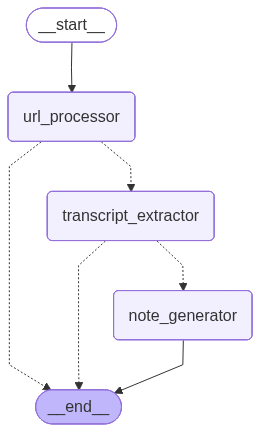


[Pipeline graph rendered above]


In [110]:
# ─── Cell 20: LangGraph StateGraph Assembly ──────────────────────────────────

builder = StateGraph(PipelineState)

# Add all nodes
builder.add_node("url_processor",        url_processor)
builder.add_node("transcript_extractor", transcript_extractor)
builder.add_node("note_generator",       note_generator)
# builder.add_node("topic_extractor",      topic_extractor)
# builder.add_node("topic_mapper",         topic_mapper)
# builder.add_node("topic_canonicalizer",  topic_canonicalizer)
# builder.add_node("graph_writer",         graph_writer_node)
# builder.add_node("topic_aggregator",     topic_aggregator)
# builder.add_node("summary_generator",    summary_generator_node)

# Entry point
builder.add_edge(START, "url_processor")

# Conditional routing: bail out early on no valid input
builder.add_conditional_edges(
    "url_processor",
    _route_after_url_processor,
    {"transcript_extractor": "transcript_extractor", END: END},
)
builder.add_conditional_edges(
    "transcript_extractor",
    _route_after_transcript_extractor,
    {"note_generator": "note_generator", END: END},
)

# Sequential pipeline
# builder.add_edge("note_generator",      "topic_extractor")
# builder.add_edge("topic_extractor",     "topic_mapper")
# builder.add_edge("topic_mapper",        "topic_canonicalizer")
# builder.add_edge("topic_canonicalizer", "graph_writer")
# builder.add_edge("graph_writer",        "topic_aggregator")
# builder.add_edge("topic_aggregator",    "summary_generator")
# builder.add_edge("summary_generator",   END)
builder.add_edge("note_generator",   END)

# Compile
pipeline = builder.compile()

print("✅ LangGraph pipeline compiled successfully")
print()
print("Pipeline nodes:")
for node_name in [
    "url_processor", "transcript_extractor", "note_generator",
    "topic_extractor", "topic_mapper", "topic_canonicalizer",
    "graph_writer", "topic_aggregator", "summary_generator"
]:
    print(f"   -> {node_name}")

# Display graph diagram
try:
    from IPython.display import Image, display
    img_bytes = pipeline.get_graph().draw_mermaid_png()
    display(Image(img_bytes))
    print("\n[Pipeline graph rendered above]")
except Exception:
    print("\nMermaid diagram source:")
    print(pipeline.get_graph().draw_mermaid())


In [ ]:
# ─── Cell 21: Retrieval & Query Layer (Phase 9 + 14) ─────────────────────────

# -- Internal: find canonical topic by name --

def _find_canonical_topic(topic_name: str) -> Optional[CanonicalTopic]:
    'Multi-strategy lookup: exact -> alias -> partial -> vector similarity.'
    all_ct = sqlite_store.get_all_canonical_topics()
    lower  = topic_name.strip().lower()

    # Strategy 1: exact name match
    for ct in all_ct:
        if ct.canonical_name.lower() == lower:
            return ct

    # Strategy 2: alias match
    for ct in all_ct:
        if any(a.lower() == lower for a in ct.aliases):
            return ct

    # Strategy 3: partial substring match
    for ct in all_ct:
        if lower in ct.canonical_name.lower():
            return ct

    # Strategy 4: vector similarity via Qdrant
    try:
        emb_model = OpenAIEmbeddings(model=MODELS["embedding"],
                                      openai_api_key=OPENAI_API_KEY)
        query_emb = emb_model.embed_query(topic_name)
        cost_tracker.record(MODELS["embedding"], count_tokens(topic_name))
        hits = qdrant_store.search_similar_topics(query_emb, top_k=1)
        if hits and hits[0]["score"] >= 0.70:
            cid = hits[0]["canonical_id"]
            for ct in all_ct:
                if ct.canonical_id == cid:
                    return ct
    except Exception as exc:
        logger.warning("Vector search failed: %s", exc)

    return None


# -- query_video --

def query_video(video_id: str) -> Dict[str, Any]:
    '''
    Return all knowledge associated with a specific video.

    Returns:
        - Video metadata
        - Full structured study notes (Markdown)
        - Topic hierarchy in original video order
        - Canonical topic IDs for cross-referencing with query_topic()
    '''
    video = sqlite_store.get_video(video_id)
    if not video:
        return {"error": f"Video '{video_id}' not found in knowledge base."}

    notes   = sqlite_store.get_structured_notes(video_id)
    t_nodes = sqlite_store.get_topic_nodes_by_video(video_id)

    def _build_tree(node: TopicNode) -> Dict:
        children = [n for n in t_nodes if n.parent_topic_id == node.topic_id]
        return {
            "topic":           node.topic_name,
            "depth":           node.depth,
            "canonical_id":    node.canonical_id,
            "content_preview": (node.content[:300] + "...") if len(node.content) > 300
                               else node.content,
            "subtopics":       [_build_tree(c) for c in children],
        }

    root_nodes = [n for n in t_nodes if n.parent_topic_id is None]
    return {
        "video_id":         video_id,
        "title":            video.title,
        "url":              video.url,
        "channel":          video.channel,
        "word_count":       video.word_count,
        "fetched_at":       video.fetched_at,
        "structured_notes": notes,
        "topic_hierarchy":  [_build_tree(r) for r in root_nodes],
        "total_topics":     len(t_nodes),
    }


# -- query_topic --

def query_topic(topic_name: str) -> Dict[str, Any]:
    '''
    Return the consolidated knowledge document for a topic concept.

    Searches by: exact name -> alias -> partial match -> vector similarity.
    Returns: aggregated Markdown content + summary + key points + graph edges.
    '''
    ct = _find_canonical_topic(topic_name)
    if not ct:
        all_names = [c.canonical_name for c in sqlite_store.get_all_canonical_topics()]
        return {
            "error":            f"Topic '{topic_name}' not found.",
            "available_topics": all_names[:20],
        }

    master = sqlite_store.get_master_document(ct.canonical_id)
    summ   = sqlite_store.get_topic_summary(ct.canonical_id)
    edges  = sqlite_store.get_graph_edges(ct.canonical_id)

    return {
        "canonical_id":     ct.canonical_id,
        "canonical_name":   ct.canonical_name,
        "aliases":          ct.aliases,
        "source_video_ids": ct.source_video_ids,
        "content":          master.content if master else "No aggregated content yet.",
        "token_count":      master.token_count if master else 0,
        "summary":          summ.summary if summ else None,
        "key_points":       summ.key_points if summ else [],
        "graph_edges":      edges[:10],
    }


# -- query_topic_summary --

def query_topic_summary(topic_name: str) -> str:
    'Return a concise formatted summary - optimised for quick retrieval.'
    result = query_topic(topic_name)
    if "error" in result:
        return f"Warning: {result['error']}"

    name       = result["canonical_name"]
    summary    = result.get("summary", "")
    key_points = result.get("key_points", [])
    aliases    = result.get("aliases", [])
    sources    = result.get("source_video_ids", [])

    if not summary:
        return f"No summary available for '{name}'."

    lines = [f"## {name}", "", summary, ""]
    if key_points:
        lines.append("**Key Points:**")
        for p in key_points:
            lines.append(f"- {p}")
        lines.append("")
    if len(aliases) > 1:
        other = [a for a in aliases if a != name]
        lines.append(f"*Also known as: {', '.join(other[:5])}*")
    lines.append(f"*Covered in {len(sources)} video(s)*")

    return "\n".join(lines)


# -- list_all_topics --

def list_all_topics() -> List[Dict]:
    'Return a sorted list of all canonical topics in the knowledge base.'
    all_ct     = sqlite_store.get_all_canonical_topics()
    summ_by_id = {s.canonical_id: s for s in sqlite_store.get_all_summaries()}
    result     = []
    for ct in all_ct:
        s       = summ_by_id.get(ct.canonical_id)
        preview = (s.summary[:120] + "...") if s and len(s.summary) > 120 \
                  else (s.summary if s else "")
        result.append({
            "canonical_name":  ct.canonical_name,
            "aliases":         ct.aliases,
            "source_count":    len(ct.source_video_ids),
            "summary_preview": preview,
        })
    return sorted(result, key=lambda x: x["canonical_name"])


# -- search_topics_semantic --

def search_topics_semantic(query: str, top_k: int = 5) -> List[Dict]:
    'Semantic search across all topic summaries using Qdrant vector similarity.'
    try:
        emb_model = OpenAIEmbeddings(model=MODELS["embedding"],
                                      openai_api_key=OPENAI_API_KEY)
        q_emb     = emb_model.embed_query(query)
        cost_tracker.record(MODELS["embedding"], count_tokens(query))
        return qdrant_store.search_summaries(q_emb, top_k=top_k)
    except Exception as exc:
        logger.error("Semantic search error: %s", exc)
        return []


# -- ask_knowledge_base --

def ask_knowledge_base(question: str, top_k: int = 3) -> str:
    'RAG-style Q&A: retrieve relevant topics, then generate an answer with GPT-4o.'
    hits = search_topics_semantic(question, top_k=top_k)
    if not hits:
        return "No relevant topics found in the knowledge base."

    context_parts = []
    for h in hits:
        ct = _find_canonical_topic(h["canonical_name"])
        if ct:
            md = sqlite_store.get_master_document(ct.canonical_id)
            if md:
                preview = md.content[:1500] + ("..." if len(md.content) > 1500 else "")
                context_parts.append(f"### {ct.canonical_name}\n{preview}")

    if not context_parts:
        return "Could not retrieve content for matched topics."

    context = "\n\n---\n\n".join(context_parts)
    prompt  = RETRIEVAL_ANSWER_PROMPT.format(context=context, question=question)
    in_tok  = count_tokens(prompt)
    llm     = make_llm(MODELS["reasoning"], temperature=0.1)
    resp    = llm.invoke([HumanMessage(content=prompt)])
    out_tok = count_tokens(resp.content)
    cost_tracker.record(MODELS["reasoning"], in_tok, out_tok)
    return resp.content


print("✅ Query layer ready:")
print("   query_video(video_id)           -> full video knowledge")
print("   query_topic(topic_name)         -> consolidated topic document")
print("   query_topic_summary(topic_name) -> concise formatted summary")
print("   list_all_topics()               -> all topics in knowledge base")
print("   search_topics_semantic(query)   -> vector similarity search")
print("   ask_knowledge_base(question)    -> RAG Q&A answer")


In [114]:
# ─── End-to-End Demo Execution ──────────────────────────────────────

DEMO_URL = "https://www.youtube.com/watch?v=jGg_1h0qzaM"

print("╔══════════════════════════════════════════════════════════════╗")
print("║              Deep Notes AI - Pipeline Execution              ║")
print("╚══════════════════════════════════════════════════════════════╝")
print()
print(f"Processing video:")
print(f"  - {DEMO_URL}")
print()

initial_state: PipelineState = {
    "url":                 DEMO_URL,
    "video_id":            "",
    "structured_notes":    "",
    "topic_nodes":         [],
    "canonical_topics":    [],
    "master_documents":    [],
    "summaries":           [],
    "errors":              [],
    "current_phase":       "init",
    "processing_complete": False,
}

# Stream execution for real-time progress
final_state = None
for step in pipeline.stream(initial_state, {"recursion_limit": 50}):
    for node_name, node_output in step.items():
        phase = node_output.get("current_phase", "")
        print(f"  [DONE] {node_name:30s} -> {phase}")
    final_state = list(step.values())[-1]

print()
print("╔══════════════════════════════════════════════════════════════╗")
print("║                    Pipeline Complete!                        ║")
print("╚══════════════════════════════════════════════════════════════╝")

if final_state:
    video     = final_state.get("video_document",  None)
    notes     = final_state.get("structured_notes", "")
    topics    = final_state.get("topic_nodes",      [])
    canonical = final_state.get("canonical_topics", [])
    summaries = final_state.get("summaries",        [])
    errors    = final_state.get("errors",           [])

    print()
    print("Results:")
    print(f"  Video processed        : {video}")
    print(f"  Notes generated        : {notes}")
    print(f"  Raw topic nodes        : {len(topics)}")
    print(f"  Canonical topics       : {len(canonical)}")
    print(f"  Topics merged          : {max(0, len(topics) - len(canonical))}")
    print(f"  Summaries generated    : {len(summaries)}")
    print(f"  Errors                 : {len(errors)}")

    if errors:
        print()
        print("Errors encountered:")
        for e in errors:
            print(f"  WARNING: {e}")

    print()
    print(cost_tracker.report())


17:06:50 [INFO] [1a] Processing URL
17:06:50 [INFO]   OK: https://www.youtube.com/watch?v=jGg_1h0qzaM -> jGg_1h0qzaM
17:06:50 [INFO] [1b] Extracting Transcript
17:06:50 [INFO]   FETCHING: jGg_1h0qzaM


╔══════════════════════════════════════════════════════════════╗
║              Deep Notes AI - Pipeline Execution              ║
╚══════════════════════════════════════════════════════════════╝

Processing video:
  - https://www.youtube.com/watch?v=jGg_1h0qzaM

  [DONE] url_processor                  -> url_processor_complete


17:06:52 [INFO]   OK: LangGraph Complete Course for Beginners – Complex AI Agents with Python | 31548 words
17:06:52 [INFO] [2] Generating Structured Notes
17:06:52 [INFO]   GENERATING notes: LangGraph Complete Course for Beginners – Complex AI Agents with Python
17:06:52 [INFO]     Processing chunk 1/2


  [DONE] transcript_extractor           -> transcript_extractor_complete


17:07:59 [INFO] HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
17:07:59 [INFO]     Processing chunk 2/2
17:08:48 [INFO] HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
17:08:48 [INFO]   OK: ~6699 tokens


  [DONE] note_generator                 -> note_generator_complete

╔══════════════════════════════════════════════════════════════╗
║                    Pipeline Complete!                        ║
╚══════════════════════════════════════════════════════════════╝

Results:
  Video processed        : None
  Notes generated        : # Type annotations (short primer)
- Purpose: provide type safety and improve readability/debuggability in Python; heavily used in Langraph for defining states.

- Dictionary vs TypedDict
  - Plain dict example:
    - movie = {"name": "Avengers Endgame", "year": 2019}
    - Problem: no structural/type guarantees → runtime/logic errors at scale.
  - TypedDict (type dictionary)
    - Implement as a class that specifies the types of keys:
      - class Movie(TypedDict):
          name: str
          year: int
      - movie: Movie = {"name": "Avengers Endgame", "year": 2019}
    - Benefits: type safety, better readability, easier debugging.
    - In Langraph: Typed

In [ ]:
# ─── Cell 23: Query Examples & Results ───────────────────────────────────────
#
# Run this cell after Cell 22 to explore your knowledge base.

from IPython.display import Markdown, display

print("=" * 60)
print("Knowledge Base Query Examples")
print("=" * 60)

# -- 1. List all topics --
print("\nExample 1: All Topics in Knowledge Base")
print("-" * 40)
all_topics = list_all_topics()
print(f"Found {len(all_topics)} canonical topic(s):")
for t in all_topics:
    src = t['source_count']
    print(f"  [{src} video(s)] {t['canonical_name']}")
    if t.get("aliases") and len(t["aliases"]) > 1:
        others = [a for a in t["aliases"] if a != t["canonical_name"]]
        if others:
            print(f"             = {', '.join(others[:3])}")

# -- 2. Query a specific topic (auto-selects first available) --
print("\nExample 2: Query Specific Topic")
print("-" * 40)
if all_topics:
    first_topic = all_topics[0]["canonical_name"]
    result = query_topic(first_topic)
    if "error" not in result:
        print(f"Topic      : {result['canonical_name']}")
        print(f"Aliases    : {result['aliases']}")
        print(f"Sources    : {result['source_video_ids']}")
        print(f"Token count: {result['token_count']:,}")
        if result.get("key_points"):
            print("Key Points:")
            for kp in result["key_points"][:3]:
                print(f"  - {kp}")
    else:
        print(result["error"])

# -- 3. Topic summary (formatted) --
print("\nExample 3: Topic Summary (Formatted)")
print("-" * 40)
if all_topics:
    first_topic = all_topics[0]["canonical_name"]
    summary_md  = query_topic_summary(first_topic)
    try:
        display(Markdown(summary_md))
    except Exception:
        print(summary_md)

# -- 4. Video query (first processed video) --
print("\nExample 4: Full Video Knowledge")
print("-" * 40)
all_videos = sqlite_store.get_all_canonical_topics()
vid_result = sqlite_store.get_all_canonical_topics()
# Get actual video IDs from the database
with sqlite_store._conn() as c:
    vid_rows = c.execute("SELECT video_id, title FROM videos LIMIT 3").fetchall()

for row in vid_rows:
    vid = query_video(row["video_id"])
    if "error" not in vid:
        print(f"Video   : {vid['title']}")
        print(f"Topics  : {vid['total_topics']}")
        notes_preview = (vid['structured_notes'] or "")[:500]
        print(f"Notes   : {notes_preview}{'...' if len(vid.get('structured_notes', '')) > 500 else ''}")
        print()

# -- 5. Semantic search --
print("\nExample 5: Semantic Search")
print("-" * 40)
if all_topics:
    first_kw = all_topics[0]["canonical_name"]
    print(f"Query: '{first_kw}'")
    hits = search_topics_semantic(first_kw, top_k=3)
    for h in hits:
        print(f"  Score {h['score']:.3f}: {h['canonical_name']}")

# -- 6. RAG Q&A --
print("\nExample 6: RAG Question & Answer")
print("-" * 40)
if all_topics:
    question = f"What is {all_topics[0]['canonical_name']} and why is it important?"
    print(f"Q: {question}")
    print()
    answer = ask_knowledge_base(question, top_k=2)
    print(f"A: {answer[:600]}{'...' if len(answer) > 600 else ''}")

print()
print("Done! Use query_video(), query_topic(), and ask_knowledge_base() interactively.")
